# This notebook shows results for the interleaved parallelization method freezing as many parameters as possible. The only varied aspects to obtain different sized datasets are:
1. Integration time (960s, 60s, 60s)
2. Number of channels (1, 1, 7)

In [11]:
import matplotlib.pyplot as plt
import matplotlib
import numpy
import os
import logging, sys
import math

from radioimaging.util import util
from radioimaging.evaluation import evaluation
from radioimaging.visibility import weights, residual
from radioimaging.deconvolution import deconvolve

matplotlib.rcParams['figure.figsize'] = [6, 5]

breakdowns = [
    "read",
    "invert",
    "predict",
    "deconvolve",
    "other"
]

breakdowns_parallel = [
    "read",
    "invert",
    "predict",
    "deconvolve",
    "wait",
    "other"
]

num_mc = 5

def total_timings(timings, breakdowns):
    total = []
    
    for i, breakdown in enumerate(breakdowns):
        curr_timing = 0

        for timing in timings:
            curr_timing += timing[i]

        total.append(curr_timing)
        
    return total

res_path = "../results/ri_parallelization_results/single_dataset/"

## Small dataset, 1969920 total, 1038045 $\mathcal{L}$, 951499 $\mathcal{H}$

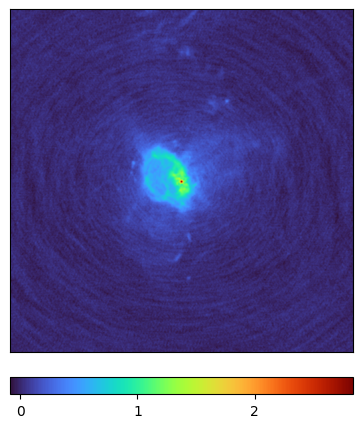

In [12]:
vl_parallel_breakdown_data = util.read_csv(res_path + "small_parallel/mc_timings_breakdown_0", separate_rows=True)
vh_parallel_breakdown_data = util.read_csv(res_path + "small_parallel/mc_timings_breakdown_1", separate_rows=True)
serial_breakdown_data = util.read_csv(res_path + "small_serial/mc_timings_breakdown", separate_rows=True)
msc_breakdown_data = util.read_csv(res_path + "small_msclean/mc_timings_breakdown", separate_rows=True)
vl_mscp_breakdown_data = util.read_csv(res_path + "small_msclean_p/mc_timings_breakdown_0", separate_rows=True)
vh_mscp_breakdown_data = util.read_csv(res_path + "small_msclean_p/mc_timings_breakdown_1", separate_rows=True)

dirty = util.fromfits(res_path + "small_serial/residual_0.fits")
util.plotNImages([dirty], [""], cmap="turbo", hide_ticks=True)

compute_jacknifed_residual = False
compute_residuals = False
computed_weighted = False

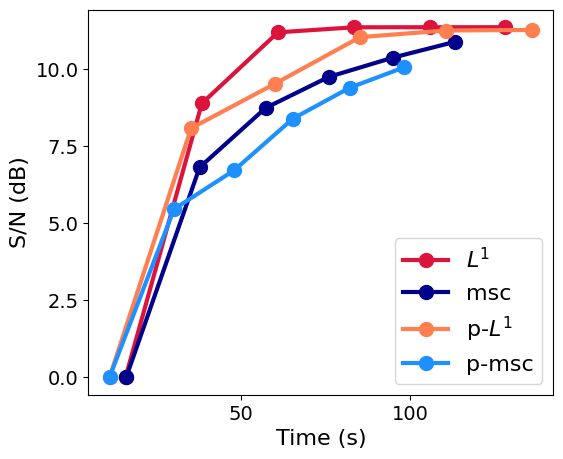

In [13]:
serial_times_sep = util.read_csv(res_path + "small_serial/mc_timings")
serial_times = []
serial_psnrs = []

msc_times_sep = util.read_csv(res_path + "small_msclean/mc_timings")
msc_times = []
msc_psnrs = []

parallel_times_sep = util.read_csv(res_path + "small_parallel/mc_timings")
parallel_times = []
vl_psnrs = []
vh_psnrs = []
combined_psnrs = []
combined_weighted_psnrs = []

parallel_msc_times_sep = util.read_csv(res_path + "small_msclean_p/mc_timings")
vlmsc_psnrs = []
vhmsc_psnrs = []
combinedmsc_psnrs = []
combinedmsc_weighted_psnrs = []
parallel_msc_times = []


gt = util.fromfits("../data/SGRA_full_gt.fits")

#For serial
curr_deconv = None
time_acc = float(serial_times_sep[0])
serial_times.append(time_acc)
serial_psnrs.append(0)
for i in range(0, num_mc):
    curr_deconv_img = util.fromfits(res_path + "small_serial/deconvolved_" + str(i) + ".fits")
    if curr_deconv is None:
        curr_deconv = curr_deconv_img
    else:
        curr_deconv += curr_deconv_img
        
    time_acc += float(serial_times_sep[i+1])

    serial_psnrs.append(evaluation.compute_snr(curr_deconv, gt))
    serial_times.append(time_acc)
    
#For msclean
curr_deconv = None
time_acc = float(msc_times_sep[0])
msc_psnrs.append(0)
msc_times.append(time_acc)
for i in range(0, num_mc):
    curr_deconv_img = util.fromfits(res_path + "small_msclean/deconvolved_" + str(i) + ".fits")
    if curr_deconv is None:
        curr_deconv = curr_deconv_img
    else:
        curr_deconv += curr_deconv_img
        
    time_acc += float(msc_times_sep[i+1])

    msc_psnrs.append(evaluation.compute_snr(curr_deconv, gt))
    msc_times.append(time_acc)

if compute_residuals:
    weight_grid, model = weights.compute_weights_griddata_from_ms("../data7/SGRA_small.ms", \
                                512, 0.00004163061962578778, 0, 0, [0])
    
if compute_jacknifed_residual:
    if weight_grid is None:
        weight_grid, model = weights.compute_weights_griddata_from_ms("../data7/SGRA_small.ms", \
                                512, 0.00004163061962578778, 0, 0, [0])
        
    jk_resid = evaluation.compute_jackknifed_residual_bychannel(model, "../data7/SGRA_small.ms",\
                                             512, 0.00004163061962578778, "uniform", 0, weight_grid, 0, 0, [0])
    util.tofits(jk_resid.pixels.data, res_path + "small_parallel/jacknifed_resid.fits")

#parallel
curr_deconv_vl = None
curr_deconv_vh = None
time_acc = float(parallel_times_sep[0])
parallel_times.append(time_acc)
vl_psnrs.append(0)
vh_psnrs.append(0)
combined_psnrs.append(0)
combined_weighted_psnrs.append(0)

for i in range(0, num_mc):
    curr_deconv_vl_img = util.fromfits(res_path + "small_parallel/deconv_vl_" + str(i) + ".fits")
    curr_deconv_vh_img = util.fromfits(res_path + "small_parallel/deconv_vh_" + str(i) + ".fits")
    if curr_deconv_vl is None:
        curr_deconv_vl = curr_deconv_vl_img
        curr_deconv_vh = curr_deconv_vh_img
    else:
        curr_deconv_vl += curr_deconv_vl_img
        curr_deconv_vh += curr_deconv_vh_img
        
    time_acc += float(parallel_times_sep[i+1])
    
    if computed_weighted:
        #weight_vl = 1 / numpy.linalg.norm(helpers.compute_windowed_var(curr_deconv_vl, 5))
        #weight_vh = 1 / numpy.linalg.norm(helpers.compute_windowed_var(curr_deconv_vh, 5))
        weight_vl = 1 / deconvolve.compute_windowed_var(curr_deconv_vl, 5)
        weight_vh = 1 / deconvolve.compute_windowed_var(curr_deconv_vh, 5)

        weight_total = weight_vl + weight_vh
        weight_vl /= weight_total
        weight_vh /= weight_total

        curr_deconv_weighted = weight_vl * curr_deconv_vl + weight_vh * curr_deconv_vh
        util.tofits(curr_deconv_weighted, res_path + "small_parallel/deconv_weighted_combined_" + str(i) + ".fits")
        
    curr_deconv_weighted = util.fromfits(res_path + "small_parallel/deconv_weighted_combined_" + str(i) + ".fits")
    curr_deconv_combined = util.fromfits(res_path + "small_parallel/deconv_combined_" + str(i) + ".fits")
    
    if compute_residuals:
        model.pixels.data[0, 0, :, :] = curr_deconv_vl
        vl_residual = residual.compute_residual_from_ms(model, "../data7/SGRA_small.ms",\
                                                 512, 0.00004163061962578778, "uniform", 0, weight_grid, \
                                                 0, 0, [0])
        model.pixels.data[0, 0, :, :] = curr_deconv_vh
        vh_residual = residual.compute_residual_from_ms(model, "../data7/SGRA_small.ms",\
                                                 512, 0.00004163061962578778, "uniform", 0, weight_grid, \
                                                 0, 0, [0])
        model.pixels.data[0, 0, :, :] = curr_deconv_combined
        combined_residual = residual.compute_residual_from_ms(model, "../data7/SGRA_small.ms",\
                                                 512, 0.00004163061962578778, "uniform", 0, weight_grid, \
                                                 0, 0, [0])
        
        util.tofits(vl_residual.pixels.data, res_path + "small_parallel/vl_fullresid_" + str(i) + ".fits")
        util.tofits(vh_residual.pixels.data, res_path + "small_parallel/vh_fullresid_" + str(i) + ".fits")
        util.tofits(combined_residual.pixels.data, res_path + "small_parallel/combined_fullresid_" + str(i) + ".fits")
        
    vl_psnrs.append(evaluation.compute_snr(curr_deconv_vl, gt))
    vh_psnrs.append(evaluation.compute_snr(curr_deconv_vh, gt))
    combined_psnrs.append(evaluation.compute_snr(curr_deconv_combined, gt))
    combined_weighted_psnrs.append(evaluation.compute_snr(curr_deconv_weighted, gt))
    parallel_times.append(time_acc)

#parallel msclean
curr_deconv_vl = None
curr_deconv_vh = None
time_acc = float(parallel_times_sep[0])

vlmsc_psnrs.append(0)
vhmsc_psnrs.append(0)
combinedmsc_psnrs.append(0)
combinedmsc_weighted_psnrs.append(0)
parallel_msc_times.append(time_acc)

for i in range(0, num_mc):
    curr_deconv_vl_img = util.fromfits(res_path + "small_msclean_p/deconv_vl_" + str(i) + ".fits")
    curr_deconv_vh_img = util.fromfits(res_path + "small_msclean_p/deconv_vh_" + str(i) + ".fits")
    if curr_deconv_vl is None:
        curr_deconv_vl = curr_deconv_vl_img
        curr_deconv_vh = curr_deconv_vh_img
    else:
        curr_deconv_vl += curr_deconv_vl_img
        curr_deconv_vh += curr_deconv_vh_img
        float(parallel_msc_times_sep[i+1])
    time_acc += float(parallel_msc_times_sep[i+1]) - float(parallel_times_sep[0]) if i == 0 else float(parallel_msc_times_sep[i+1])
    
    if computed_weighted:
        weight_vl = 1 / numpy.linalg.norm(deconvolve.compute_windowed_var(curr_deconv_vl, 5))
        weight_vh = 1 / numpy.linalg.norm(deconvolve.compute_windowed_var(curr_deconv_vh, 5))

        print(str(weight_vl) + " " + str(weight_vh))

        weight_total = weight_vl + weight_vh
        weight_vl /= weight_total
        weight_vh /= weight_total

        curr_deconv_weighted = weight_vl * curr_deconv_vl + weight_vh * curr_deconv_vh
        util.tofits(curr_deconv_weighted, res_path + "small_msclean_p/deconv_weighted_combined_" + str(i) + ".fits")
        
    curr_deconv_weighted = util.fromfits(res_path + "small_msclean_p/deconv_weighted_combined_" + str(i) + ".fits")
    curr_deconv_combined = util.fromfits(res_path + "small_msclean_p/deconv_combined_" + str(i) + ".fits")
      
    vlmsc_psnrs.append(evaluation.compute_snr(curr_deconv_vl, gt))
    vhmsc_psnrs.append(evaluation.compute_snr(curr_deconv_vh, gt))
    combinedmsc_psnrs.append(evaluation.compute_snr(curr_deconv_combined, gt))
    combinedmsc_weighted_psnrs.append(evaluation.compute_snr(curr_deconv_weighted, gt))
    parallel_msc_times.append(time_acc)
    
plt.plot(serial_times, serial_psnrs, c='crimson', label="$L^1$", lw=3, marker='o', markersize=10)
plt.plot(msc_times, msc_psnrs, c='darkblue', label="msc", lw=3, marker='o', markersize=10)
#plt.plot(parallel_times, vl_psnrs, c='teal', label="${V}_\mathcal{L}$ recon", lw=2, marker='o')
#plt.plot(parallel_times, vh_psnrs, c='purple', label="${V}_\mathcal{H}$ recon", lw=2, marker='o')
plt.plot(parallel_times, combined_psnrs, c='coral', label="p-$L^1$", lw=3, marker='o', markersize=10)
#plt.plot(parallel_times, combined_weighted_psnrs, c='darkorange', label="combined weighted parallel recon", lw=2, marker='o')

#plt.plot(parallel_times, vlmsc_psnrs, c='powderblue', label="msclean ${V}_\mathcal{L}$ recon", lw=2, marker='o')
#plt.plot(parallel_times, vhmsc_psnrs, c='plum', label="msclean ${V}_\mathcal{H}$ recon", lw=2, marker='o')
plt.plot(parallel_msc_times, combinedmsc_psnrs, c='dodgerblue', label="p-msc", lw=3, marker='o', markersize=10)
#plt.plot(parallel_times, combinedmsc_weighted_psnrs, c='moccasin', label="msclean combined weighted parallel recon", lw=2, marker='o')

plt.xlabel("Time (s)", fontsize=16)
plt.ylabel("S/N (dB)", fontsize=16)
#plt.yscale('log')
plt.legend(loc="lower right", fontsize=16)
plt.locator_params(nbins=5)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.show()

## L1 breakdown

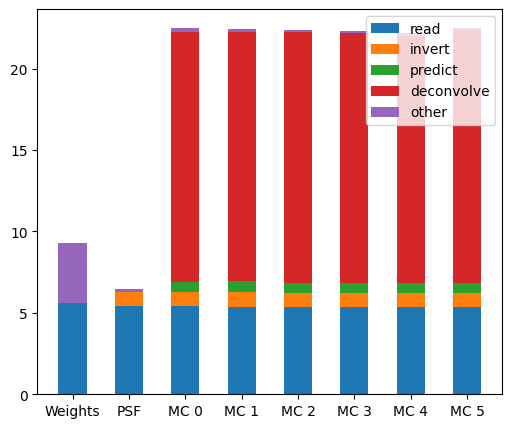

In [14]:
for i, lst in enumerate(serial_breakdown_data):
    serial_breakdown_data[i] = list(map(float, lst))

serial_weights_timings = serial_breakdown_data[1]
serial_psf_timings = serial_breakdown_data[2]

serial_mc_timings = serial_breakdown_data[3:]

width = 0.5

labels = [
    "Weights",
    "PSF"
]
    
bottom = numpy.zeros(len(serial_mc_timings) + 2)
    
fig, ax = plt.subplots()

timings = []
timings.append([serial_weights_timings[0], 0, 0, 0, sum(serial_weights_timings[1:])])
timings.append([serial_psf_timings[0], serial_psf_timings[3], 0, 0, sum(serial_psf_timings[1:3]) + serial_psf_timings[4]])

for i, curr_mc_timings in enumerate(serial_mc_timings):
    labels.append("MC " + str(i))
    other_timings = sum(curr_mc_timings[1:4]) + curr_mc_timings[5] + curr_mc_timings[7]
    timings.append([curr_mc_timings[0], curr_mc_timings[6], curr_mc_timings[4], curr_mc_timings[8], other_timings])
    
for i, curr_breakdown in enumerate(breakdowns):
    curr_breakdown_timing = []
    for curr_timing in timings:
        curr_breakdown_timing.append(curr_timing[i])
    
    p = ax.bar(labels, curr_breakdown_timing, width, label=curr_breakdown, bottom=bottom)
    bottom += curr_breakdown_timing
    
small_timings_serial = total_timings(timings, breakdowns)
    
ax.legend(loc="upper right")
plt.show()

## ms-clean breakdown

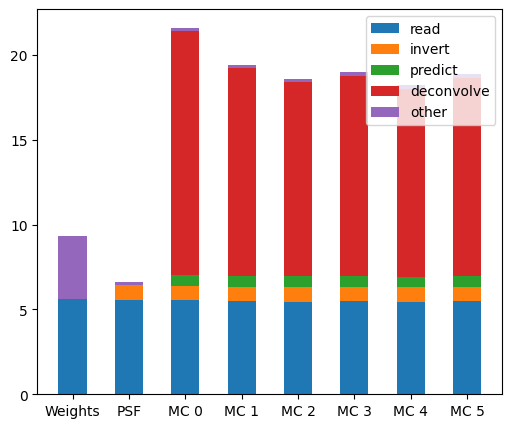

In [15]:
for i, lst in enumerate(msc_breakdown_data):
    msc_breakdown_data[i] = list(map(float, lst))

msc_weights_timings = msc_breakdown_data[1]
msc_psf_timings = msc_breakdown_data[2]

msc_mc_timings = msc_breakdown_data[3:]

width = 0.5

labels = [
    "Weights",
    "PSF"
]
    
bottom = numpy.zeros(len(msc_mc_timings) + 2)
    
fig, ax = plt.subplots()

timings = []
timings.append([msc_weights_timings[0], 0, 0, 0, sum(msc_weights_timings[1:])])
timings.append([msc_psf_timings[0], msc_psf_timings[3], 0, 0, sum(msc_psf_timings[1:3]) + msc_psf_timings[4]])

for i, curr_mc_timings in enumerate(msc_mc_timings):
    labels.append("MC " + str(i))
    other_timings = sum(curr_mc_timings[1:4]) + curr_mc_timings[5] + curr_mc_timings[7]
    timings.append([curr_mc_timings[0], curr_mc_timings[6], curr_mc_timings[4], curr_mc_timings[8], other_timings])
    
for i, curr_breakdown in enumerate(breakdowns):
    curr_breakdown_timing = []
    for curr_timing in timings:
        curr_breakdown_timing.append(curr_timing[i])
    
    p = ax.bar(labels, curr_breakdown_timing, width, label=curr_breakdown, bottom=bottom)
    bottom += curr_breakdown_timing
    
small_timings_msc = total_timings(timings, breakdowns)
    
ax.legend(loc="upper right")
plt.show()

## L1 $\text{V}_\mathcal{L}$ breakdown

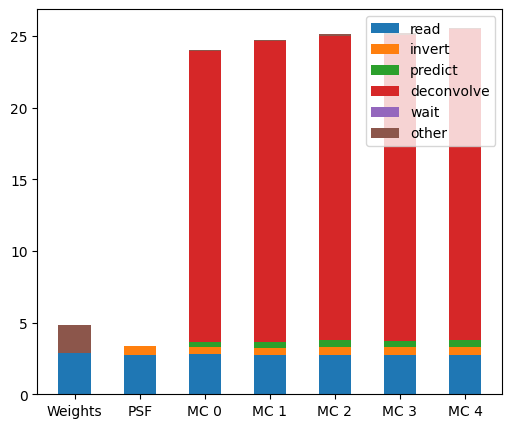

In [16]:
for i, lst in enumerate(vl_parallel_breakdown_data):
    vl_parallel_breakdown_data[i] = list(map(float, lst))

vl_weights_timings = vl_parallel_breakdown_data[1]
vl_psf_timings = vl_parallel_breakdown_data[2]
vl_wait_timings = vl_parallel_breakdown_data[3]
vl_mc_timings = vl_parallel_breakdown_data[4:]

width = 0.5

labels = [
    "Weights",
    "PSF"
]
    
bottom = numpy.zeros(len(vl_mc_timings) + 2)
    
fig, ax = plt.subplots()

timings = []
timings.append([vl_weights_timings[0], 0, 0, 0, 0, sum(vl_weights_timings[1:])])
timings.append([vl_psf_timings[0], vl_psf_timings[3], 0, 0, 0, sum(vl_psf_timings[1:2]) + vl_psf_timings[4]])

for i, curr_mc_timings in enumerate(vl_mc_timings):
    labels.append("MC " + str(i))
    other_timings = sum(curr_mc_timings[2:5]) + curr_mc_timings[6] + curr_mc_timings[8]
    timings.append([curr_mc_timings[1], curr_mc_timings[7], curr_mc_timings[5], curr_mc_timings[9], \
                    curr_mc_timings[0] + curr_mc_timings[10], other_timings])
    
for i, curr_breakdown in enumerate(breakdowns_parallel):
    curr_breakdown_timing = []
    for curr_timing in timings:
        curr_breakdown_timing.append(curr_timing[i])

    p = ax.bar(labels, curr_breakdown_timing, width, label=curr_breakdown, bottom=bottom)
    bottom += curr_breakdown_timing
    
small_timings_vl = total_timings(timings, breakdowns_parallel)
    
ax.legend(loc="upper right")
plt.show()

## L1 $\text{V}_\mathcal{H}$ breakdown

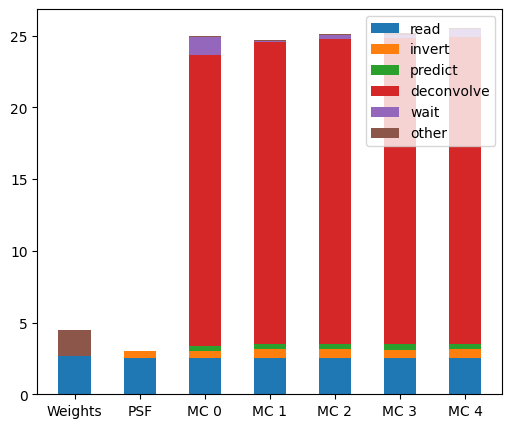

In [17]:
for i, lst in enumerate(vh_parallel_breakdown_data):
    vh_parallel_breakdown_data[i] = list(map(float, lst))

vh_weights_timings = vh_parallel_breakdown_data[1]
vh_psf_timings = vh_parallel_breakdown_data[2]
vh_wait_timings = vh_parallel_breakdown_data[3]
vh_mc_timings = vh_parallel_breakdown_data[4:]

width = 0.5

labels = [
    "Weights",
    "PSF"
]
    
bottom = numpy.zeros(len(vh_mc_timings) + 2)
    
fig, ax = plt.subplots()

timings = []
timings.append([vh_weights_timings[0], 0, 0, 0, 0, sum(vh_weights_timings[1:])])
timings.append([vh_psf_timings[0], vh_psf_timings[3], 0, 0, 0, sum(vh_psf_timings[1:2]) + vh_psf_timings[4]])

for i, curr_mc_timings in enumerate(vh_mc_timings):
    labels.append("MC " + str(i))
    other_timings = sum(curr_mc_timings[2:5]) + curr_mc_timings[6] + curr_mc_timings[8]
    timings.append([curr_mc_timings[1], curr_mc_timings[7], curr_mc_timings[5], curr_mc_timings[9], \
                    curr_mc_timings[0] + curr_mc_timings[10], other_timings])
    
for i, curr_breakdown in enumerate(breakdowns_parallel):
    curr_breakdown_timing = []
    for curr_timing in timings:
        curr_breakdown_timing.append(curr_timing[i])

    p = ax.bar(labels, curr_breakdown_timing, width, label=curr_breakdown, bottom=bottom)
    bottom += curr_breakdown_timing
    
small_timings_vh = total_timings(timings, breakdowns_parallel)
    
ax.legend(loc="upper right")
plt.show()

## msclean $\text{V}_\mathcal{L}$ breakdown

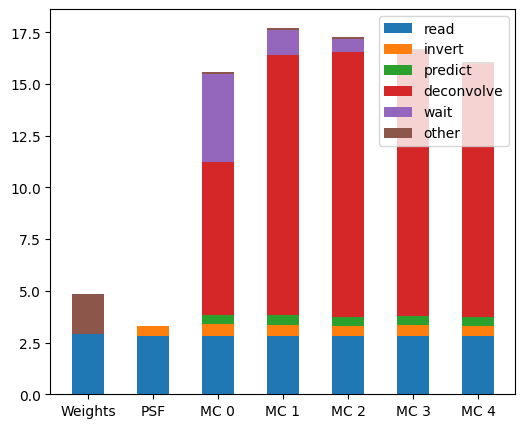

In [18]:
for i, lst in enumerate(vl_mscp_breakdown_data):
    vl_mscp_breakdown_data[i] = list(map(float, lst))

vl_mscp_weights_timings = vl_mscp_breakdown_data[1]
vl_mscp_psf_timings = vl_mscp_breakdown_data[2]
vl_mscp_wait_timings = vl_mscp_breakdown_data[3]
vl_mscp_mc_timings = vl_mscp_breakdown_data[4:]

width = 0.5

labels = [
    "Weights",
    "PSF"
]
    
bottom = numpy.zeros(len(vl_mscp_mc_timings) + 2)
    
fig, ax = plt.subplots()

timings = []
timings.append([vl_mscp_weights_timings[0], 0, 0, 0, 0, sum(vl_mscp_weights_timings[1:])])
timings.append([vl_mscp_psf_timings[0], vl_mscp_psf_timings[3], 0, 0, 0, sum(vl_mscp_psf_timings[1:2]) + vl_mscp_psf_timings[4]])

for i, curr_mc_timings in enumerate(vl_mscp_mc_timings):
    labels.append("MC " + str(i))
    other_timings = sum(curr_mc_timings[2:5]) + curr_mc_timings[6] + curr_mc_timings[8]
    timings.append([curr_mc_timings[1], curr_mc_timings[7], curr_mc_timings[5], curr_mc_timings[9], \
                    curr_mc_timings[0] + curr_mc_timings[10], other_timings])
    
for i, curr_breakdown in enumerate(breakdowns_parallel):
    curr_breakdown_timing = []
    for curr_timing in timings:
        curr_breakdown_timing.append(curr_timing[i])

    p = ax.bar(labels, curr_breakdown_timing, width, label=curr_breakdown, bottom=bottom)
    bottom += curr_breakdown_timing
    
small_timings_mscp_vl = total_timings(timings, breakdowns_parallel)
    
ax.legend(loc="upper right")
plt.show()

## msclean $\text{V}_\mathcal{H}$ breakdown

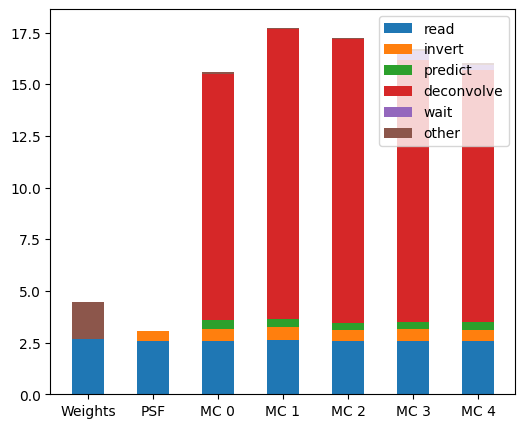

In [19]:
for i, lst in enumerate(vh_mscp_breakdown_data):
    vh_mscp_breakdown_data[i] = list(map(float, lst))

vh_mscp_weights_timings = vh_mscp_breakdown_data[1]
vh_mscp_psf_timings = vh_mscp_breakdown_data[2]
vh_mscp_wait_timings = vh_mscp_breakdown_data[3]
vh_mscp_mc_timings = vh_mscp_breakdown_data[4:]

width = 0.5

labels = [
    "Weights",
    "PSF"
]
    
bottom = numpy.zeros(len(vh_mscp_mc_timings) + 2)
    
fig, ax = plt.subplots()

timings = []
timings.append([vh_mscp_weights_timings[0], 0, 0, 0, 0, sum(vh_mscp_weights_timings[1:])])
timings.append([vh_mscp_psf_timings[0], vh_mscp_psf_timings[3], 0, 0, 0, sum(vh_mscp_psf_timings[1:2]) + vh_mscp_psf_timings[4]])

for i, curr_mc_timings in enumerate(vh_mscp_mc_timings):
    labels.append("MC " + str(i))
    other_timings = sum(curr_mc_timings[2:5]) + curr_mc_timings[6] + curr_mc_timings[8]
    timings.append([curr_mc_timings[1], curr_mc_timings[7], curr_mc_timings[5], curr_mc_timings[9], \
                    curr_mc_timings[0] + curr_mc_timings[10], other_timings])
    
for i, curr_breakdown in enumerate(breakdowns_parallel):
    curr_breakdown_timing = []
    for curr_timing in timings:
        curr_breakdown_timing.append(curr_timing[i])

    p = ax.bar(labels, curr_breakdown_timing, width, label=curr_breakdown, bottom=bottom)
    bottom += curr_breakdown_timing
    
small_timings_mscp_vh = total_timings(timings, breakdowns_parallel)
    
ax.legend(loc="upper right")
plt.show()

## Medium dataset, 15759360 total, 8304401 $\mathcal{L}$, 7611946 $\mathcal{H}$

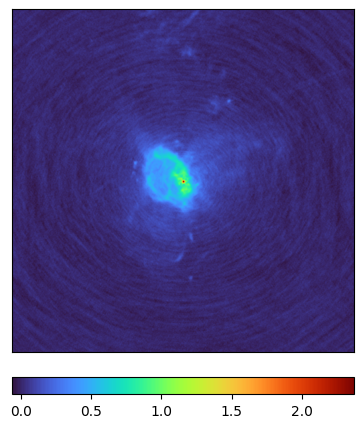

In [23]:
vl_parallel_breakdown_data = util.read_csv(res_path + "mid_parallel/mc_timings_breakdown_0", separate_rows=True)
vh_parallel_breakdown_data = util.read_csv(res_path + "mid_parallel/mc_timings_breakdown_1", separate_rows=True)
serial_breakdown_data = util.read_csv(res_path + "mid_serial/mc_timings_breakdown", separate_rows=True)
msc_breakdown_data = util.read_csv(res_path + "mid_msclean/mc_timings_breakdown", separate_rows=True)
vl_mscp_breakdown_data = util.read_csv(res_path + "mid_msclean_p/mc_timings_breakdown_0", separate_rows=True)
vh_mscp_breakdown_data = util.read_csv(res_path + "mid_msclean_p/mc_timings_breakdown_1", separate_rows=True)

dirty = util.fromfits(res_path + "mid_serial/residual_0.fits")
util.plotNImages([dirty], [""], cmap="turbo", hide_ticks=True)

compute_jacknifed_residual = False
compute_residuals = False
computed_weighted = False

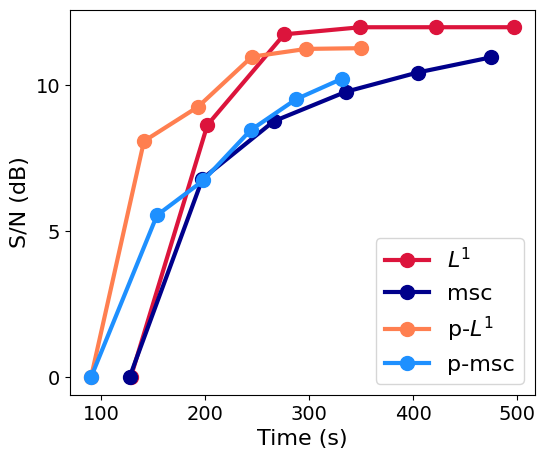

In [24]:
serial_times_sep = util.read_csv(res_path + "mid_serial/mc_timings")
serial_times = []
serial_psnrs = []

msc_times_sep = util.read_csv(res_path + "mid_msclean/mc_timings")
msc_times = []
msc_psnrs = []

parallel_times_sep = util.read_csv(res_path + "mid_parallel/mc_timings")
parallel_times = []
vl_psnrs = []
vh_psnrs = []
combined_psnrs = []
combined_weighted_psnrs = []

parallel_msc_times_sep = util.read_csv(res_path + "mid_msclean_p/mc_timings")
vlmsc_psnrs = []
vhmsc_psnrs = []
combinedmsc_psnrs = []
combinedmsc_weighted_psnrs = []
parallel_msc_times = []


gt = util.fromfits("../data/SGRA_full_gt.fits")

#For serial
curr_deconv = None
time_acc = float(serial_times_sep[0])
serial_times.append(time_acc)
serial_psnrs.append(0)
for i in range(0, num_mc):
    curr_deconv_img = util.fromfits(res_path + "mid_serial/deconvolved_" + str(i) + ".fits")
    if curr_deconv is None:
        curr_deconv = curr_deconv_img
    else:
        curr_deconv += curr_deconv_img
        
    time_acc += float(serial_times_sep[i+1])

    serial_psnrs.append(evaluation.compute_snr(curr_deconv, gt))
    serial_times.append(time_acc)
    
#For msclean
curr_deconv = None
time_acc = float(msc_times_sep[0])
msc_psnrs.append(0)
msc_times.append(time_acc)
for i in range(0, num_mc):
    curr_deconv_img = util.fromfits(res_path + "mid_msclean/deconvolved_" + str(i) + ".fits")
    if curr_deconv is None:
        curr_deconv = curr_deconv_img
    else:
        curr_deconv += curr_deconv_img
        
    time_acc += float(msc_times_sep[i+1])

    msc_psnrs.append(evaluation.compute_snr(curr_deconv, gt))
    msc_times.append(time_acc)

if compute_residuals:
    weight_grid, model = weights.compute_weights_griddata_from_ms("../data7/SGRA_mid.ms", \
                                512, 0.00004163064219060362, 0, 0, [0])
    
if compute_jacknifed_residual:
    if weight_grid is None:
        weight_grid, model = weights.compute_weights_griddata_from_ms("../data7/SGRA_mid.ms", \
                                512, 0.00004163064219060362, 0, 0, [0])
        
    jk_resid = evaluation.compute_jackknifed_residual_bychannel(model, "../data7/SGRA_mid.ms",\
                                             512, 0.00004163064219060362, "uniform", 0, weight_grid, 0, 0, [0])
    util.tofits(jk_resid.pixels.data, res_path + "mid_parallel/jacknifed_resid.fits")

#parallel
curr_deconv_vl = None
curr_deconv_vh = None
time_acc = float(parallel_times_sep[0])
parallel_times.append(time_acc)
vl_psnrs.append(0)
vh_psnrs.append(0)
combined_psnrs.append(0)
combined_weighted_psnrs.append(0)

for i in range(0, num_mc):
    curr_deconv_vl_img = util.fromfits(res_path + "mid_parallel/deconv_vl_" + str(i) + ".fits")
    curr_deconv_vh_img = util.fromfits(res_path + "mid_parallel/deconv_vh_" + str(i) + ".fits")
    if curr_deconv_vl is None:
        curr_deconv_vl = curr_deconv_vl_img
        curr_deconv_vh = curr_deconv_vh_img
    else:
        curr_deconv_vl += curr_deconv_vl_img
        curr_deconv_vh += curr_deconv_vh_img
        
    time_acc += float(parallel_times_sep[i+1])
    
    if computed_weighted:
        #weight_vl = 1 / numpy.linalg.norm(helpers.compute_windowed_var(curr_deconv_vl, 5))
        #weight_vh = 1 / numpy.linalg.norm(helpers.compute_windowed_var(curr_deconv_vh, 5))
        weight_vl = 1 / deconvolve.compute_windowed_var(curr_deconv_vl, 5)
        weight_vh = 1 / deconvolve.compute_windowed_var(curr_deconv_vh, 5)

        weight_total = weight_vl + weight_vh
        weight_vl /= weight_total
        weight_vh /= weight_total

        curr_deconv_weighted = weight_vl * curr_deconv_vl + weight_vh * curr_deconv_vh
        util.tofits(curr_deconv_weighted, res_path + "mid_parallel/deconv_weighted_combined_" + str(i) + ".fits")
        
    curr_deconv_weighted = util.fromfits(res_path + "mid_parallel/deconv_weighted_combined_" + str(i) + ".fits")
    curr_deconv_combined = util.fromfits(res_path + "mid_parallel/deconv_combined_" + str(i) + ".fits")
    
    if compute_residuals:
        model.pixels.data[0, 0, :, :] = curr_deconv_vl
        vl_residual = residual.compute_residual_from_ms(model, "../data7/SGRA_mid.ms",\
                                                 512, 0.00004163061962578778, "uniform", 0, weight_grid, \
                                                 0, 0, [0])
        model.pixels.data[0, 0, :, :] = curr_deconv_vh
        vh_residual = residual.compute_residual_from_ms(model, "../data7/SGRA_mid.ms",\
                                                 512, 0.00004163061962578778, "uniform", 0, weight_grid, \
                                                 0, 0, [0])
        model.pixels.data[0, 0, :, :] = curr_deconv_combined
        combined_residual = residual.compute_residual_from_ms(model, "../data7/SGRA_mid.ms",\
                                                 512, 0.00004163061962578778, "uniform", 0, weight_grid, \
                                                 0, 0, [0])
        
        util.tofits(vl_residual.pixels.data, res_path + "mid_parallel/vl_fullresid_" + str(i) + ".fits")
        util.tofits(vh_residual.pixels.data, res_path + "mid_parallel/vh_fullresid_" + str(i) + ".fits")
        util.tofits(combined_residual.pixels.data, res_path + "mid_parallel/combined_fullresid_" + str(i) + ".fits")
        
    vl_psnrs.append(evaluation.compute_snr(curr_deconv_vl, gt))
    vh_psnrs.append(evaluation.compute_snr(curr_deconv_vh, gt))
    combined_psnrs.append(evaluation.compute_snr(curr_deconv_combined, gt))
    combined_weighted_psnrs.append(evaluation.compute_snr(curr_deconv_weighted, gt))
    parallel_times.append(time_acc)

#parallel msclean
curr_deconv_vl = None
curr_deconv_vh = None
time_acc = float(parallel_times_sep[0])

vlmsc_psnrs.append(0)
vhmsc_psnrs.append(0)
combinedmsc_psnrs.append(0)
combinedmsc_weighted_psnrs.append(0)
parallel_msc_times.append(time_acc)

for i in range(0, num_mc):
    curr_deconv_vl_img = util.fromfits(res_path + "mid_msclean_p/deconv_vl_" + str(i) + ".fits")
    curr_deconv_vh_img = util.fromfits(res_path + "mid_msclean_p/deconv_vh_" + str(i) + ".fits")
    if curr_deconv_vl is None:
        curr_deconv_vl = curr_deconv_vl_img
        curr_deconv_vh = curr_deconv_vh_img
    else:
        curr_deconv_vl += curr_deconv_vl_img
        curr_deconv_vh += curr_deconv_vh_img
        float(parallel_msc_times_sep[i+1])
    time_acc += float(parallel_msc_times_sep[i+1]) - float(parallel_times_sep[0]) if i == 0 else float(parallel_msc_times_sep[i+1])
    
    if computed_weighted:
        weight_vl = 1 / numpy.linalg.norm(evaluation.compute_windowed_var(curr_deconv_vl, 5))
        weight_vh = 1 / numpy.linalg.norm(evaluation.compute_windowed_var(curr_deconv_vh, 5))

        print(str(weight_vl) + " " + str(weight_vh))

        weight_total = weight_vl + weight_vh
        weight_vl /= weight_total
        weight_vh /= weight_total

        curr_deconv_weighted = weight_vl * curr_deconv_vl + weight_vh * curr_deconv_vh
        util.tofits(curr_deconv_weighted, res_path + "mid_msclean_p/deconv_weighted_combined_" + str(i) + ".fits")
        
    curr_deconv_weighted = util.fromfits(res_path + "mid_msclean_p/deconv_weighted_combined_" + str(i) + ".fits")
    curr_deconv_combined = util.fromfits(res_path + "mid_msclean_p/deconv_combined_" + str(i) + ".fits")
      
    vlmsc_psnrs.append(evaluation.compute_snr(curr_deconv_vl, gt))
    vhmsc_psnrs.append(evaluation.compute_snr(curr_deconv_vh, gt))
    combinedmsc_psnrs.append(evaluation.compute_snr(curr_deconv_combined, gt))
    combinedmsc_weighted_psnrs.append(evaluation.compute_snr(curr_deconv_weighted, gt))
    parallel_msc_times.append(time_acc)
    
plt.plot(serial_times, serial_psnrs, c='crimson', label="$L^1$", lw=3, marker='o', markersize=10)
plt.plot(msc_times, msc_psnrs, c='darkblue', label="msc", lw=3, marker='o', markersize=10)
#plt.plot(parallel_times, vl_psnrs, c='teal', label="${V}_\mathcal{L}$ recon", lw=2, marker='o')
#plt.plot(parallel_times, vh_psnrs, c='purple', label="${V}_\mathcal{H}$ recon", lw=2, marker='o')
plt.plot(parallel_times, combined_psnrs, c='coral', label="p-$L^1$", lw=3, marker='o', markersize=10)
#plt.plot(parallel_times, combined_weighted_psnrs, c='darkorange', label="combined weighted parallel recon", lw=2, marker='o')

#plt.plot(parallel_times, vlmsc_psnrs, c='powderblue', label="msclean ${V}_\mathcal{L}$ recon", lw=2, marker='o')
#plt.plot(parallel_times, vhmsc_psnrs, c='plum', label="msclean ${V}_\mathcal{H}$ recon", lw=2, marker='o')
plt.plot(parallel_msc_times, combinedmsc_psnrs, c='dodgerblue', label="p-msc", lw=3, marker='o', markersize=10)
#plt.plot(parallel_times, combinedmsc_weighted_psnrs, c='moccasin', label="msclean combined weighted parallel recon", lw=2, marker='o')

plt.xlabel("Time (s)", fontsize=16)
plt.ylabel("S/N (dB)", fontsize=16)
#plt.yscale('log')
plt.legend(loc="lower right", fontsize=16)
plt.locator_params(nbins=5)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.show()

## L1 breakdown

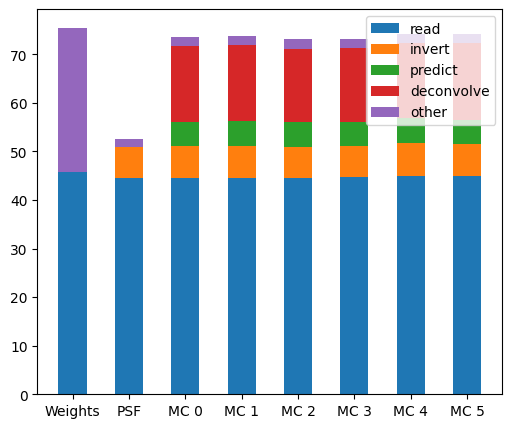

In [25]:
for i, lst in enumerate(serial_breakdown_data):
    serial_breakdown_data[i] = list(map(float, lst))

serial_weights_timings = serial_breakdown_data[1]
serial_psf_timings = serial_breakdown_data[2]

serial_mc_timings = serial_breakdown_data[3:]

width = 0.5

labels = [
    "Weights",
    "PSF"
]
    
bottom = numpy.zeros(len(serial_mc_timings) + 2)
    
fig, ax = plt.subplots()

timings = []
timings.append([serial_weights_timings[0], 0, 0, 0, sum(serial_weights_timings[1:])])
timings.append([serial_psf_timings[0], serial_psf_timings[3], 0, 0, sum(serial_psf_timings[1:3]) + serial_psf_timings[4]])

for i, curr_mc_timings in enumerate(serial_mc_timings):
    labels.append("MC " + str(i))
    other_timings = sum(curr_mc_timings[1:4]) + curr_mc_timings[5] + curr_mc_timings[7]
    timings.append([curr_mc_timings[0], curr_mc_timings[6], curr_mc_timings[4], curr_mc_timings[8], other_timings])
    
for i, curr_breakdown in enumerate(breakdowns):
    curr_breakdown_timing = []
    for curr_timing in timings:
        curr_breakdown_timing.append(curr_timing[i])
    
    p = ax.bar(labels, curr_breakdown_timing, width, label=curr_breakdown, bottom=bottom)
    bottom += curr_breakdown_timing
    
mid_timings_serial = total_timings(timings, breakdowns)
    
ax.legend(loc="upper right")
plt.show()

## ms-clean breakdown

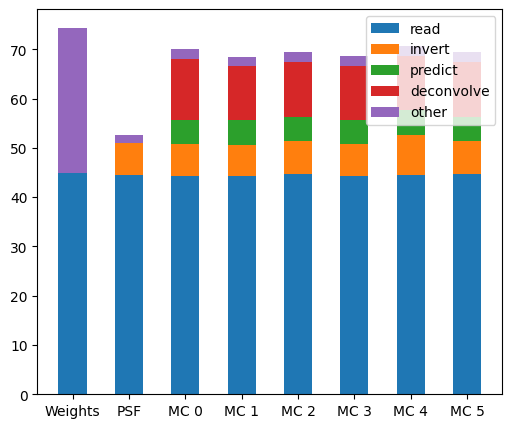

In [26]:
for i, lst in enumerate(msc_breakdown_data):
    msc_breakdown_data[i] = list(map(float, lst))

msc_weights_timings = msc_breakdown_data[1]
msc_psf_timings = msc_breakdown_data[2]

msc_mc_timings = msc_breakdown_data[3:]

width = 0.5

labels = [
    "Weights",
    "PSF"
]
    
bottom = numpy.zeros(len(msc_mc_timings) + 2)
    
fig, ax = plt.subplots()

timings = []
timings.append([msc_weights_timings[0], 0, 0, 0, sum(msc_weights_timings[1:])])
timings.append([msc_psf_timings[0], msc_psf_timings[3], 0, 0, sum(msc_psf_timings[1:3]) + msc_psf_timings[4]])

for i, curr_mc_timings in enumerate(msc_mc_timings):
    labels.append("MC " + str(i))
    other_timings = sum(curr_mc_timings[1:4]) + curr_mc_timings[5] + curr_mc_timings[7]
    timings.append([curr_mc_timings[0], curr_mc_timings[6], curr_mc_timings[4], curr_mc_timings[8], other_timings])
    
for i, curr_breakdown in enumerate(breakdowns):
    curr_breakdown_timing = []
    for curr_timing in timings:
        curr_breakdown_timing.append(curr_timing[i])
    
    p = ax.bar(labels, curr_breakdown_timing, width, label=curr_breakdown, bottom=bottom)
    bottom += curr_breakdown_timing
    
mid_timings_msc = total_timings(timings, breakdowns)
    
ax.legend(loc="upper right")
plt.show()

## L1 $\text{V}_\mathcal{L}$ breakdown

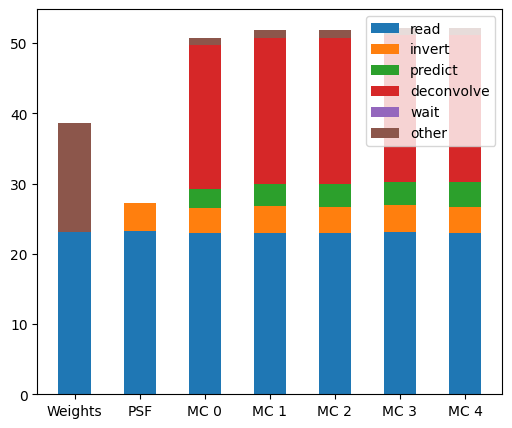

In [27]:
for i, lst in enumerate(vl_parallel_breakdown_data):
    vl_parallel_breakdown_data[i] = list(map(float, lst))

vl_weights_timings = vl_parallel_breakdown_data[1]
vl_psf_timings = vl_parallel_breakdown_data[2]
vl_wait_timings = vl_parallel_breakdown_data[3]
vl_mc_timings = vl_parallel_breakdown_data[4:]

width = 0.5

labels = [
    "Weights",
    "PSF"
]
    
bottom = numpy.zeros(len(vl_mc_timings) + 2)
    
fig, ax = plt.subplots()

timings = []
timings.append([vl_weights_timings[0], 0, 0, 0, 0, sum(vl_weights_timings[1:])])
timings.append([vl_psf_timings[0], vl_psf_timings[3], 0, 0, 0, sum(vl_psf_timings[1:2]) + vl_psf_timings[4]])

for i, curr_mc_timings in enumerate(vl_mc_timings):
    labels.append("MC " + str(i))
    other_timings = sum(curr_mc_timings[2:5]) + curr_mc_timings[6] + curr_mc_timings[8]
    timings.append([curr_mc_timings[1], curr_mc_timings[7], curr_mc_timings[5], curr_mc_timings[9], \
                    curr_mc_timings[0] + curr_mc_timings[10], other_timings])
    
for i, curr_breakdown in enumerate(breakdowns_parallel):
    curr_breakdown_timing = []
    for curr_timing in timings:
        curr_breakdown_timing.append(curr_timing[i])

    p = ax.bar(labels, curr_breakdown_timing, width, label=curr_breakdown, bottom=bottom)
    bottom += curr_breakdown_timing
    
mid_timings_vl = total_timings(timings, breakdowns_parallel)
    
ax.legend(loc="upper right")
plt.show()

## L1 $\text{V}_\mathcal{H}$ breakdown

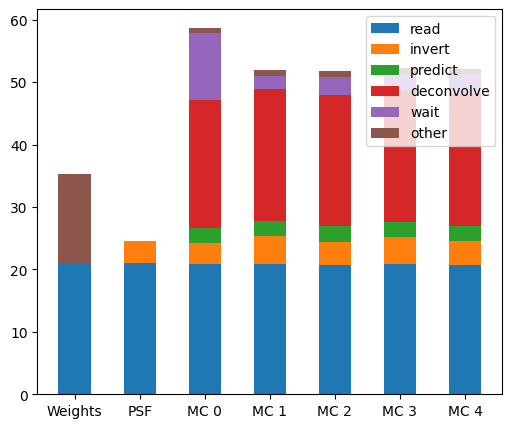

In [28]:
for i, lst in enumerate(vh_parallel_breakdown_data):
    vh_parallel_breakdown_data[i] = list(map(float, lst))

vh_weights_timings = vh_parallel_breakdown_data[1]
vh_psf_timings = vh_parallel_breakdown_data[2]
vh_wait_timings = vh_parallel_breakdown_data[3]
vh_mc_timings = vh_parallel_breakdown_data[4:]

width = 0.5

labels = [
    "Weights",
    "PSF"
]
    
bottom = numpy.zeros(len(vh_mc_timings) + 2)
    
fig, ax = plt.subplots()

timings = []
timings.append([vh_weights_timings[0], 0, 0, 0, 0, sum(vh_weights_timings[1:])])
timings.append([vh_psf_timings[0], vh_psf_timings[3], 0, 0, 0, sum(vh_psf_timings[1:2]) + vh_psf_timings[4]])

for i, curr_mc_timings in enumerate(vh_mc_timings):
    labels.append("MC " + str(i))
    other_timings = sum(curr_mc_timings[2:5]) + curr_mc_timings[6] + curr_mc_timings[8]
    timings.append([curr_mc_timings[1], curr_mc_timings[7], curr_mc_timings[5], curr_mc_timings[9], \
                    curr_mc_timings[0] + curr_mc_timings[10], other_timings])
    
for i, curr_breakdown in enumerate(breakdowns_parallel):
    curr_breakdown_timing = []
    for curr_timing in timings:
        curr_breakdown_timing.append(curr_timing[i])

    p = ax.bar(labels, curr_breakdown_timing, width, label=curr_breakdown, bottom=bottom)
    bottom += curr_breakdown_timing
    
mid_timings_vh = total_timings(timings, breakdowns_parallel)
    
ax.legend(loc="upper right")
plt.show()

## msclean $\text{V}_\mathcal{L}$ breakdown

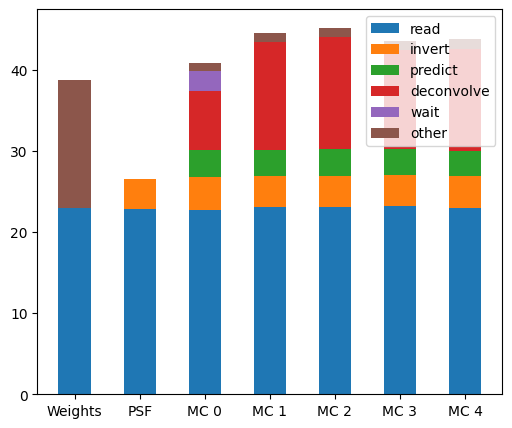

In [29]:
for i, lst in enumerate(vl_mscp_breakdown_data):
    vl_mscp_breakdown_data[i] = list(map(float, lst))

vl_mscp_weights_timings = vl_mscp_breakdown_data[1]
vl_mscp_psf_timings = vl_mscp_breakdown_data[2]
vl_mscp_wait_timings = vl_mscp_breakdown_data[3]
vl_mscp_mc_timings = vl_mscp_breakdown_data[4:]

width = 0.5

labels = [
    "Weights",
    "PSF"
]
    
bottom = numpy.zeros(len(vl_mscp_mc_timings) + 2)
    
fig, ax = plt.subplots()

timings = []
timings.append([vl_mscp_weights_timings[0], 0, 0, 0, 0, sum(vl_mscp_weights_timings[1:])])
timings.append([vl_mscp_psf_timings[0], vl_mscp_psf_timings[3], 0, 0, 0, sum(vl_mscp_psf_timings[1:2]) + vl_mscp_psf_timings[4]])

for i, curr_mc_timings in enumerate(vl_mscp_mc_timings):
    labels.append("MC " + str(i))
    other_timings = sum(curr_mc_timings[2:5]) + curr_mc_timings[6] + curr_mc_timings[8]
    timings.append([curr_mc_timings[1], curr_mc_timings[7], curr_mc_timings[5], curr_mc_timings[9], \
                    curr_mc_timings[0] + curr_mc_timings[10], other_timings])
    
for i, curr_breakdown in enumerate(breakdowns_parallel):
    curr_breakdown_timing = []
    for curr_timing in timings:
        curr_breakdown_timing.append(curr_timing[i])

    p = ax.bar(labels, curr_breakdown_timing, width, label=curr_breakdown, bottom=bottom)
    bottom += curr_breakdown_timing
    
mid_timings_mscp_vl = total_timings(timings, breakdowns_parallel)
    
ax.legend(loc="upper right")
plt.show()

## msclean $\text{V}_\mathcal{H}$ breakdown

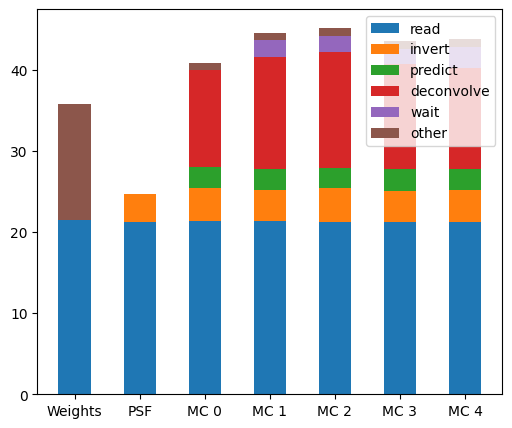

In [30]:
for i, lst in enumerate(vh_mscp_breakdown_data):
    vh_mscp_breakdown_data[i] = list(map(float, lst))

vh_mscp_weights_timings = vh_mscp_breakdown_data[1]
vh_mscp_psf_timings = vh_mscp_breakdown_data[2]
vh_mscp_wait_timings = vh_mscp_breakdown_data[3]
vh_mscp_mc_timings = vh_mscp_breakdown_data[4:]

width = 0.5

labels = [
    "Weights",
    "PSF"
]
    
bottom = numpy.zeros(len(vh_mscp_mc_timings) + 2)
    
fig, ax = plt.subplots()

timings = []
timings.append([vh_mscp_weights_timings[0], 0, 0, 0, 0, sum(vh_mscp_weights_timings[1:])])
timings.append([vh_mscp_psf_timings[0], vh_mscp_psf_timings[3], 0, 0, 0, sum(vh_mscp_psf_timings[1:2]) + vh_mscp_psf_timings[4]])

for i, curr_mc_timings in enumerate(vh_mscp_mc_timings):
    labels.append("MC " + str(i))
    other_timings = sum(curr_mc_timings[2:5]) + curr_mc_timings[6] + curr_mc_timings[8]
    timings.append([curr_mc_timings[1], curr_mc_timings[7], curr_mc_timings[5], curr_mc_timings[9], \
                    curr_mc_timings[0] + curr_mc_timings[10], other_timings])
    
for i, curr_breakdown in enumerate(breakdowns_parallel):
    curr_breakdown_timing = []
    for curr_timing in timings:
        curr_breakdown_timing.append(curr_timing[i])

    p = ax.bar(labels, curr_breakdown_timing, width, label=curr_breakdown, bottom=bottom)
    bottom += curr_breakdown_timing
    
mid_timings_mscp_vh = total_timings(timings, breakdowns_parallel)
    
ax.legend(loc="upper right")
plt.show()

## Large dataset, 110315520 total, 62033811 $\mathcal{L}$, 51918524 $\mathcal{H}$

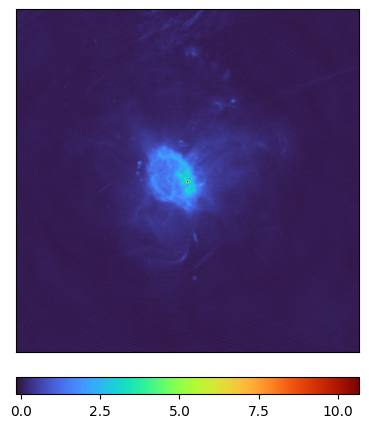

In [31]:
vl_parallel_breakdown_data = util.read_csv(res_path + "large_parallel/mc_timings_breakdown_0", separate_rows=True)
vh_parallel_breakdown_data = util.read_csv(res_path + "large_parallel/mc_timings_breakdown_1", separate_rows=True)
serial_breakdown_data = util.read_csv(res_path + "large_serial/mc_timings_breakdown", separate_rows=True)
msc_breakdown_data = util.read_csv(res_path + "large_msclean/mc_timings_breakdown", separate_rows=True)
vl_mscp_breakdown_data = util.read_csv(res_path + "large_msclean_p/mc_timings_breakdown_0", separate_rows=True)
vh_mscp_breakdown_data = util.read_csv(res_path + "large_msclean_p/mc_timings_breakdown_1", separate_rows=True)

dirty = util.fromfits(res_path + "large_serial/residual_0.fits")
util.plotNImages([dirty], [""], cmap="turbo", hide_ticks=True)

compute_jacknifed_residual = False
compute_residuals = False
computed_weighted = False

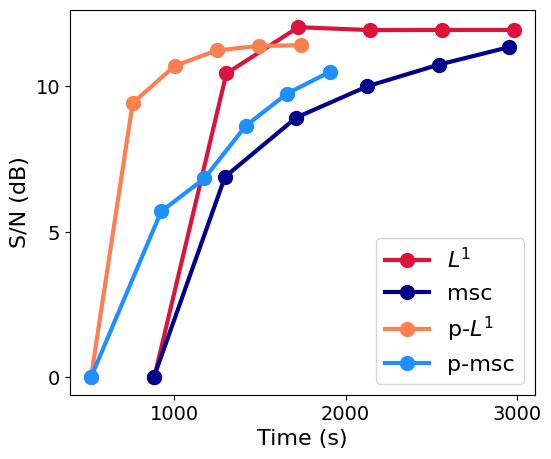

In [33]:
serial_times_sep = util.read_csv(res_path + "large_serial/mc_timings")
serial_times = []
serial_psnrs = []

msc_times_sep = util.read_csv(res_path + "large_msclean/mc_timings")
msc_times = []
msc_psnrs = []

parallel_times_sep = util.read_csv(res_path + "large_parallel/mc_timings")
parallel_times = []
vl_psnrs = []
vh_psnrs = []
combined_psnrs = []
combined_weighted_psnrs = []

parallel_msc_times_sep = util.read_csv(res_path + "large_msclean_p/mc_timings")
vlmsc_psnrs = []
vhmsc_psnrs = []
combinedmsc_psnrs = []
combinedmsc_weighted_psnrs = []
parallel_msc_times = []


gt = util.fromfits("../data/SGRA_full_gt.fits")

#For serial
curr_deconv = None
time_acc = float(serial_times_sep[0])
serial_times.append(time_acc)
serial_psnrs.append(0)
for i in range(0, num_mc):
    curr_deconv_img = util.fromfits(res_path + "large_serial/deconvolved_" + str(i) + ".fits")
    if curr_deconv is None:
        curr_deconv = curr_deconv_img
    else:
        curr_deconv += curr_deconv_img
        
    time_acc += float(serial_times_sep[i+1])

    serial_psnrs.append(evaluation.compute_snr(curr_deconv, gt))
    serial_times.append(time_acc)
    
#For msclean
curr_deconv = None
time_acc = float(msc_times_sep[0])
msc_psnrs.append(0)
msc_times.append(time_acc)
for i in range(0, num_mc):
    curr_deconv_img = util.fromfits(res_path + "large_msclean/deconvolved_" + str(i) + ".fits")
    if curr_deconv is None:
        curr_deconv = curr_deconv_img
    else:
        curr_deconv += curr_deconv_img
        
    time_acc += float(msc_times_sep[i+1])

    msc_psnrs.append(evaluation.compute_snr(curr_deconv, gt))
    msc_times.append(time_acc)

if compute_residuals:
    weight_grid, model = weights.compute_weights_griddata_from_ms("../data7/SGRA_large.ms", \
                                512, 0.00003717021624161038, 0, 6, [0])
    
if compute_jacknifed_residual:
    if weight_grid is None:
        weight_grid, model = weights.compute_weights_griddata_from_ms("../data7/SGRA_large.ms", \
                                512, 0.00003717021624161038, 0, 6, [0])
        
    jk_resid = evaluation.compute_jackknifed_residual_bychannel(model, "../data7/SGRA_large.ms",\
                                             512, 0.00003717021624161038, "uniform", 0, weight_grid, 0, 6, [0])
    util.tofits(jk_resid.pixels.data, res_path + "large_parallel/jacknifed_resid.fits")

#parallel
curr_deconv_vl = None
curr_deconv_vh = None
time_acc = float(parallel_times_sep[0])
parallel_times.append(time_acc)
vl_psnrs.append(0)
vh_psnrs.append(0)
combined_psnrs.append(0)
combined_weighted_psnrs.append(0)

for i in range(0, num_mc):
    curr_deconv_vl_img = util.fromfits(res_path + "large_parallel/deconv_vl_" + str(i) + ".fits")
    curr_deconv_vh_img = util.fromfits(res_path + "large_parallel/deconv_vh_" + str(i) + ".fits")
    if curr_deconv_vl is None:
        curr_deconv_vl = curr_deconv_vl_img
        curr_deconv_vh = curr_deconv_vh_img
    else:
        curr_deconv_vl += curr_deconv_vl_img
        curr_deconv_vh += curr_deconv_vh_img
        
    time_acc += float(parallel_times_sep[i+1])
    
    if computed_weighted:
        #weight_vl = 1 / numpy.linalg.norm(helpers.compute_windowed_var(curr_deconv_vl, 5))
        #weight_vh = 1 / numpy.linalg.norm(helpers.compute_windowed_var(curr_deconv_vh, 5))
        weight_vl = 1 / deconvolve.compute_windowed_var(curr_deconv_vl, 5)
        weight_vh = 1 / deconvolve.compute_windowed_var(curr_deconv_vh, 5)

        weight_total = weight_vl + weight_vh
        weight_vl /= weight_total
        weight_vh /= weight_total

        curr_deconv_weighted = weight_vl * curr_deconv_vl + weight_vh * curr_deconv_vh
        util.tofits(curr_deconv_weighted, res_path + "large_parallel/deconv_weighted_combined_" + str(i) + ".fits")
        
    curr_deconv_weighted = util.fromfits(res_path + "large_parallel/deconv_weighted_combined_" + str(i) + ".fits")
    curr_deconv_combined = util.fromfits(res_path + "large_parallel/deconv_combined_" + str(i) + ".fits")
    
    if compute_residuals:
        model.pixels.data[0, 0, :, :] = curr_deconv_vl
        vl_residual = residual.compute_residual_from_ms(model, "../data7/SGRA_large.ms",\
                                                 512, 0.00003717021624161038, "uniform", 0, weight_grid, \
                                                 0, 6, [0])
        model.pixels.data[0, 0, :, :] = curr_deconv_vh
        vh_residual = residual.compute_residual_from_ms(model, "../data7/SGRA_large.ms",\
                                                 512, 0.00003717021624161038, "uniform", 0, weight_grid, \
                                                 0, 6, [0])
        model.pixels.data[0, 0, :, :] = curr_deconv_combined
        combined_residual = residual.compute_residual_from_ms(model, "../data7/SGRA_large.ms",\
                                                 512, 0.00003717021624161038, "uniform", 0, weight_grid, \
                                                 0, 6, [0])
        
        util.tofits(vl_residual.pixels.data, res_path + "large_parallel/vl_fullresid_" + str(i) + ".fits")
        util.tofits(vh_residual.pixels.data, res_path + "large_parallel/vh_fullresid_" + str(i) + ".fits")
        util.tofits(combined_residual.pixels.data, res_path + "large_parallel/combined_fullresid_" + str(i) + ".fits")
        
    vl_psnrs.append(evaluation.compute_snr(curr_deconv_vl, gt))
    vh_psnrs.append(evaluation.compute_snr(curr_deconv_vh, gt))
    combined_psnrs.append(evaluation.compute_snr(curr_deconv_combined, gt))
    combined_weighted_psnrs.append(evaluation.compute_snr(curr_deconv_weighted, gt))
    parallel_times.append(time_acc)

#parallel msclean
curr_deconv_vl = None
curr_deconv_vh = None
time_acc = float(parallel_times_sep[0])

vlmsc_psnrs.append(0)
vhmsc_psnrs.append(0)
combinedmsc_psnrs.append(0)
combinedmsc_weighted_psnrs.append(0)
parallel_msc_times.append(time_acc)

for i in range(0, num_mc):
    curr_deconv_vl_img = util.fromfits(res_path + "large_msclean_p/deconv_vl_" + str(i) + ".fits")
    curr_deconv_vh_img = util.fromfits(res_path + "large_msclean_p/deconv_vh_" + str(i) + ".fits")
    if curr_deconv_vl is None:
        curr_deconv_vl = curr_deconv_vl_img
        curr_deconv_vh = curr_deconv_vh_img
    else:
        curr_deconv_vl += curr_deconv_vl_img
        curr_deconv_vh += curr_deconv_vh_img
        float(parallel_msc_times_sep[i+1])
    time_acc += float(parallel_msc_times_sep[i+1]) - float(parallel_times_sep[0]) if i == 0 else float(parallel_msc_times_sep[i+1])
    
    if computed_weighted:
        weight_vl = 1 / numpy.linalg.norm(deconvolve.compute_windowed_var(curr_deconv_vl, 5))
        weight_vh = 1 / numpy.linalg.norm(deconvolve.compute_windowed_var(curr_deconv_vh, 5))

        print(str(weight_vl) + " " + str(weight_vh))

        weight_total = weight_vl + weight_vh
        weight_vl /= weight_total
        weight_vh /= weight_total

        curr_deconv_weighted = weight_vl * curr_deconv_vl + weight_vh * curr_deconv_vh
        util.tofits(curr_deconv_weighted, res_path + "large_msclean_p/deconv_weighted_combined_" + str(i) + ".fits")
        
    curr_deconv_weighted = util.fromfits(res_path + "large_msclean_p/deconv_weighted_combined_" + str(i) + ".fits")
    curr_deconv_combined = util.fromfits(res_path + "large_msclean_p/deconv_combined_" + str(i) + ".fits")
      
    vlmsc_psnrs.append(evaluation.compute_snr(curr_deconv_vl, gt))
    vhmsc_psnrs.append(evaluation.compute_snr(curr_deconv_vh, gt))
    combinedmsc_psnrs.append(evaluation.compute_snr(curr_deconv_combined, gt))
    combinedmsc_weighted_psnrs.append(evaluation.compute_snr(curr_deconv_weighted, gt))
    parallel_msc_times.append(time_acc)
    
plt.plot(serial_times, serial_psnrs, c='crimson', label="$L^1$", lw=3, marker='o', markersize=10)
plt.plot(msc_times, msc_psnrs, c='darkblue', label="msc", lw=3, marker='o', markersize=10)
#plt.plot(parallel_times, vl_psnrs, c='teal', label="${V}_\mathcal{L}$ recon", lw=2, marker='o')
#plt.plot(parallel_times, vh_psnrs, c='purple', label="${V}_\mathcal{H}$ recon", lw=2, marker='o')
plt.plot(parallel_times, combined_psnrs, c='coral', label="p-$L^1$", lw=3, marker='o', markersize=10)
#plt.plot(parallel_times, combined_weighted_psnrs, c='darkorange', label="combined weighted parallel recon", lw=2, marker='o')

#plt.plot(parallel_times, vlmsc_psnrs, c='powderblue', label="msclean ${V}_\mathcal{L}$ recon", lw=2, marker='o')
#plt.plot(parallel_times, vhmsc_psnrs, c='plum', label="msclean ${V}_\mathcal{H}$ recon", lw=2, marker='o')
plt.plot(parallel_msc_times, combinedmsc_psnrs, c='dodgerblue', label="p-msc", lw=3, marker='o', markersize=10)
#plt.plot(parallel_times, combinedmsc_weighted_psnrs, c='moccasin', label="msclean combined weighted parallel recon", lw=2, marker='o')

plt.xlabel("Time (s)", fontsize=16)
plt.ylabel("S/N (dB)", fontsize=16)
#plt.yscale('log')
plt.legend(loc="lower right", fontsize=16)
plt.locator_params(nbins=5)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.show()

## L1 breakdown

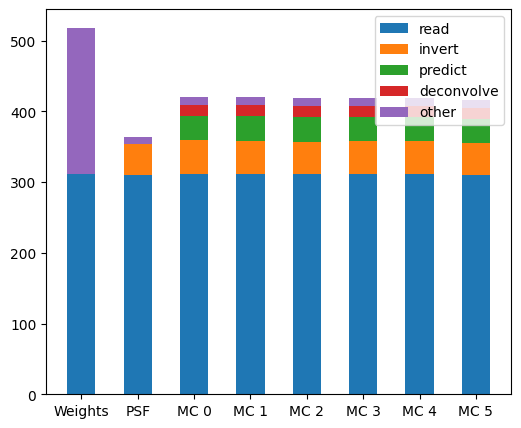

In [34]:
for i, lst in enumerate(serial_breakdown_data):
    serial_breakdown_data[i] = list(map(float, lst))

serial_weights_timings = serial_breakdown_data[1]
serial_psf_timings = serial_breakdown_data[2]

serial_mc_timings = serial_breakdown_data[3:]

width = 0.5

labels = [
    "Weights",
    "PSF"
]
    
bottom = numpy.zeros(len(serial_mc_timings) + 2)
    
fig, ax = plt.subplots()

timings = []
timings.append([serial_weights_timings[0], 0, 0, 0, sum(serial_weights_timings[1:])])
timings.append([serial_psf_timings[0], serial_psf_timings[3], 0, 0, sum(serial_psf_timings[1:3]) + serial_psf_timings[4]])

for i, curr_mc_timings in enumerate(serial_mc_timings):
    labels.append("MC " + str(i))
    other_timings = sum(curr_mc_timings[1:4]) + curr_mc_timings[5] + curr_mc_timings[7]
    timings.append([curr_mc_timings[0], curr_mc_timings[6], curr_mc_timings[4], curr_mc_timings[8], other_timings])
    
for i, curr_breakdown in enumerate(breakdowns):
    curr_breakdown_timing = []
    for curr_timing in timings:
        curr_breakdown_timing.append(curr_timing[i])
    
    p = ax.bar(labels, curr_breakdown_timing, width, label=curr_breakdown, bottom=bottom)
    bottom += curr_breakdown_timing
    
large_timings_serial = total_timings(timings, breakdowns)
    
ax.legend(loc="upper right")
plt.show()

## ms-clean breakdown

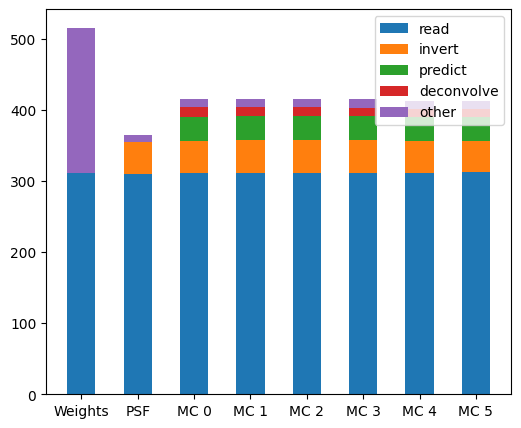

In [35]:
for i, lst in enumerate(msc_breakdown_data):
    msc_breakdown_data[i] = list(map(float, lst))

msc_weights_timings = msc_breakdown_data[1]
msc_psf_timings = msc_breakdown_data[2]

msc_mc_timings = msc_breakdown_data[3:]

width = 0.5

labels = [
    "Weights",
    "PSF"
]
    
bottom = numpy.zeros(len(msc_mc_timings) + 2)
    
fig, ax = plt.subplots()

timings = []
timings.append([msc_weights_timings[0], 0, 0, 0, sum(msc_weights_timings[1:])])
timings.append([msc_psf_timings[0], msc_psf_timings[3], 0, 0, sum(msc_psf_timings[1:3]) + msc_psf_timings[4]])

for i, curr_mc_timings in enumerate(msc_mc_timings):
    labels.append("MC " + str(i))
    other_timings = sum(curr_mc_timings[1:4]) + curr_mc_timings[5] + curr_mc_timings[7]
    timings.append([curr_mc_timings[0], curr_mc_timings[6], curr_mc_timings[4], curr_mc_timings[8], other_timings])
    
for i, curr_breakdown in enumerate(breakdowns):
    curr_breakdown_timing = []
    for curr_timing in timings:
        curr_breakdown_timing.append(curr_timing[i])
    
    p = ax.bar(labels, curr_breakdown_timing, width, label=curr_breakdown, bottom=bottom)
    bottom += curr_breakdown_timing
    
large_timings_msc = total_timings(timings, breakdowns)
    
ax.legend(loc="upper right")
plt.show()

## L1 $\text{V}_\mathcal{L}$ breakdown

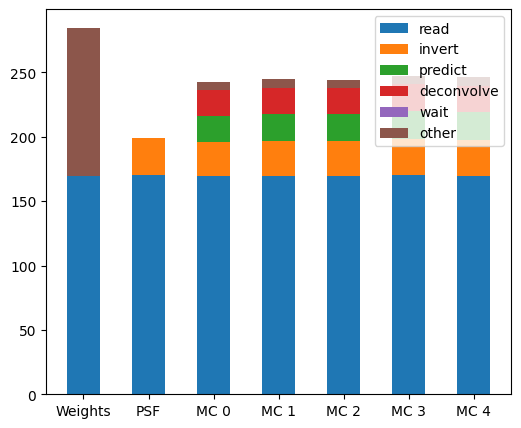

In [36]:
for i, lst in enumerate(vl_parallel_breakdown_data):
    vl_parallel_breakdown_data[i] = list(map(float, lst))

vl_weights_timings = vl_parallel_breakdown_data[1]
vl_psf_timings = vl_parallel_breakdown_data[2]
vl_wait_timings = vl_parallel_breakdown_data[3]
vl_mc_timings = vl_parallel_breakdown_data[4:]

width = 0.5

labels = [
    "Weights",
    "PSF"
]
    
bottom = numpy.zeros(len(vl_mc_timings) + 2)
    
fig, ax = plt.subplots()

timings = []
timings.append([vl_weights_timings[0], 0, 0, 0, 0, sum(vl_weights_timings[1:])])
timings.append([vl_psf_timings[0], vl_psf_timings[3], 0, 0, 0, sum(vl_psf_timings[1:2]) + vl_psf_timings[4]])

for i, curr_mc_timings in enumerate(vl_mc_timings):
    labels.append("MC " + str(i))
    other_timings = sum(curr_mc_timings[2:5]) + curr_mc_timings[6] + curr_mc_timings[8]
    timings.append([curr_mc_timings[1], curr_mc_timings[7], curr_mc_timings[5], curr_mc_timings[9], \
                    curr_mc_timings[0] + curr_mc_timings[10], other_timings])
    
for i, curr_breakdown in enumerate(breakdowns_parallel):
    curr_breakdown_timing = []
    for curr_timing in timings:
        curr_breakdown_timing.append(curr_timing[i])

    p = ax.bar(labels, curr_breakdown_timing, width, label=curr_breakdown, bottom=bottom)
    bottom += curr_breakdown_timing
    
large_timings_vl = total_timings(timings, breakdowns_parallel)
    
ax.legend(loc="upper right")
plt.show()

## L1 $\text{V}_\mathcal{H}$ breakdown

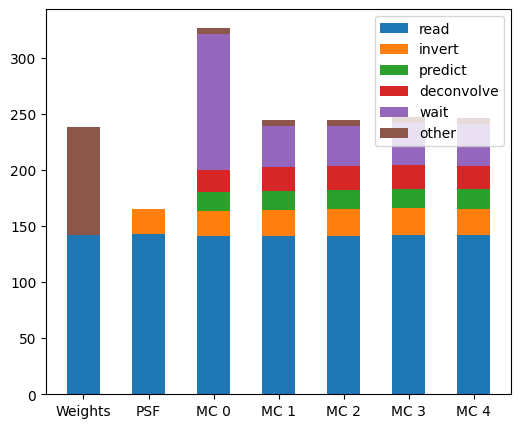

In [37]:
for i, lst in enumerate(vh_parallel_breakdown_data):
    vh_parallel_breakdown_data[i] = list(map(float, lst))

vh_weights_timings = vh_parallel_breakdown_data[1]
vh_psf_timings = vh_parallel_breakdown_data[2]
vh_wait_timings = vh_parallel_breakdown_data[3]
vh_mc_timings = vh_parallel_breakdown_data[4:]

width = 0.5

labels = [
    "Weights",
    "PSF"
]
    
bottom = numpy.zeros(len(vh_mc_timings) + 2)
    
fig, ax = plt.subplots()

timings = []
timings.append([vh_weights_timings[0], 0, 0, 0, 0, sum(vh_weights_timings[1:])])
timings.append([vh_psf_timings[0], vh_psf_timings[3], 0, 0, 0, sum(vh_psf_timings[1:2]) + vh_psf_timings[4]])

for i, curr_mc_timings in enumerate(vh_mc_timings):
    labels.append("MC " + str(i))
    other_timings = sum(curr_mc_timings[2:5]) + curr_mc_timings[6] + curr_mc_timings[8]
    timings.append([curr_mc_timings[1], curr_mc_timings[7], curr_mc_timings[5], curr_mc_timings[9], \
                    curr_mc_timings[0] + curr_mc_timings[10], other_timings])
    
for i, curr_breakdown in enumerate(breakdowns_parallel):
    curr_breakdown_timing = []
    for curr_timing in timings:
        curr_breakdown_timing.append(curr_timing[i])

    p = ax.bar(labels, curr_breakdown_timing, width, label=curr_breakdown, bottom=bottom)
    bottom += curr_breakdown_timing
    
large_timings_vh = total_timings(timings, breakdowns_parallel)
    
ax.legend(loc="upper right")
plt.show()

## msclean $\text{V}_\mathcal{L}$ breakdown

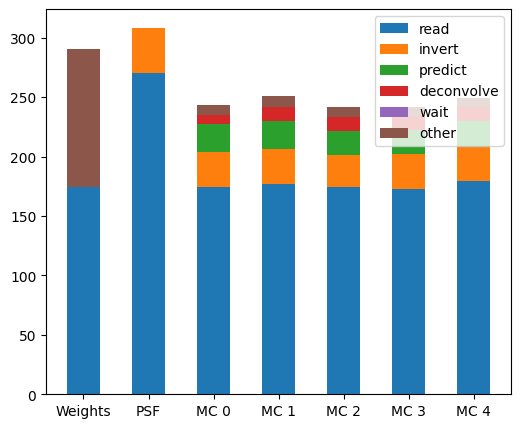

In [38]:
for i, lst in enumerate(vl_mscp_breakdown_data):
    vl_mscp_breakdown_data[i] = list(map(float, lst))

vl_mscp_weights_timings = vl_mscp_breakdown_data[1]
vl_mscp_psf_timings = vl_mscp_breakdown_data[2]
vl_mscp_wait_timings = vl_mscp_breakdown_data[3]
vl_mscp_mc_timings = vl_mscp_breakdown_data[4:]

width = 0.5

labels = [
    "Weights",
    "PSF"
]
    
bottom = numpy.zeros(len(vl_mscp_mc_timings) + 2)
    
fig, ax = plt.subplots()

timings = []
timings.append([vl_mscp_weights_timings[0], 0, 0, 0, 0, sum(vl_mscp_weights_timings[1:])])
timings.append([vl_mscp_psf_timings[0], vl_mscp_psf_timings[3], 0, 0, 0, sum(vl_mscp_psf_timings[1:2]) + vl_mscp_psf_timings[4]])

for i, curr_mc_timings in enumerate(vl_mscp_mc_timings):
    labels.append("MC " + str(i))
    other_timings = sum(curr_mc_timings[2:5]) + curr_mc_timings[6] + curr_mc_timings[8]
    timings.append([curr_mc_timings[1], curr_mc_timings[7], curr_mc_timings[5], curr_mc_timings[9], \
                    curr_mc_timings[0] + curr_mc_timings[10], other_timings])
    
for i, curr_breakdown in enumerate(breakdowns_parallel):
    curr_breakdown_timing = []
    for curr_timing in timings:
        curr_breakdown_timing.append(curr_timing[i])

    p = ax.bar(labels, curr_breakdown_timing, width, label=curr_breakdown, bottom=bottom)
    bottom += curr_breakdown_timing
    
large_timings_mscp_vl = total_timings(timings, breakdowns_parallel)
    
ax.legend(loc="upper right")
plt.show()

## msclean $\text{V}_\mathcal{H}$ breakdown

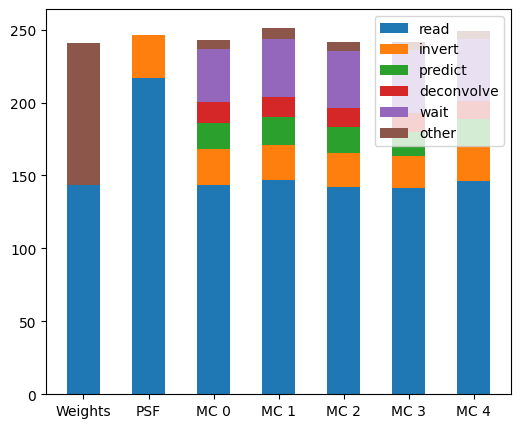

In [39]:
for i, lst in enumerate(vh_mscp_breakdown_data):
    vh_mscp_breakdown_data[i] = list(map(float, lst))

vh_mscp_weights_timings = vh_mscp_breakdown_data[1]
vh_mscp_psf_timings = vh_mscp_breakdown_data[2]
vh_mscp_wait_timings = vh_mscp_breakdown_data[3]
vh_mscp_mc_timings = vh_mscp_breakdown_data[4:]

width = 0.5

labels = [
    "Weights",
    "PSF"
]
    
bottom = numpy.zeros(len(vh_mscp_mc_timings) + 2)
    
fig, ax = plt.subplots()

timings = []
timings.append([vh_mscp_weights_timings[0], 0, 0, 0, 0, sum(vh_mscp_weights_timings[1:])])
timings.append([vh_mscp_psf_timings[0], vh_mscp_psf_timings[3], 0, 0, 0, sum(vh_mscp_psf_timings[1:2]) + vh_mscp_psf_timings[4]])

for i, curr_mc_timings in enumerate(vh_mscp_mc_timings):
    labels.append("MC " + str(i))
    other_timings = sum(curr_mc_timings[2:5]) + curr_mc_timings[6] + curr_mc_timings[8]
    timings.append([curr_mc_timings[1], curr_mc_timings[7], curr_mc_timings[5], curr_mc_timings[9], \
                    curr_mc_timings[0] + curr_mc_timings[10], other_timings])
    
for i, curr_breakdown in enumerate(breakdowns_parallel):
    curr_breakdown_timing = []
    for curr_timing in timings:
        curr_breakdown_timing.append(curr_timing[i])

    p = ax.bar(labels, curr_breakdown_timing, width, label=curr_breakdown, bottom=bottom)
    bottom += curr_breakdown_timing
    
large_timings_mscp_vh = total_timings(timings, breakdowns_parallel)
    
ax.legend(loc="upper right")
plt.show()

In [40]:
labels=["$L^1$", "msc", "p-$L^1V_\mathcal{L}$", "p-$L^1V_\mathcal{H}$", "p-msc$V_\mathcal{L}$", "p-msc$V_\mathcal{H}$"]
matplotlib.rcParams['figure.figsize'] = [8, 5]

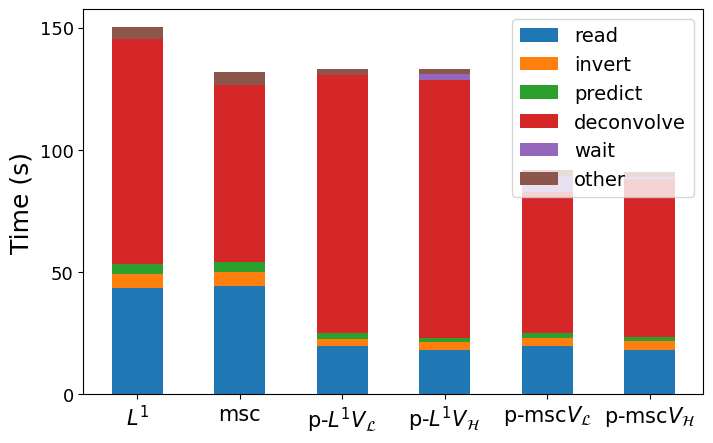

In [41]:
fig, ax = plt.subplots()

bottom = numpy.zeros(6)

for i, curr_breakdown in enumerate(breakdowns_parallel):
    curr_timings = None
    if i == 4:
        curr_timings = [0, 0, small_timings_vl[i], small_timings_vh[i], small_timings_mscp_vl[i], small_timings_mscp_vh[i]]
    elif i > 4:
        curr_timings = [small_timings_serial[i - 1], small_timings_msc[i - 1], small_timings_vl[i], small_timings_vh[i], small_timings_mscp_vl[i], small_timings_mscp_vh[i]]
    else:
        curr_timings = [small_timings_serial[i], small_timings_msc[i], small_timings_vl[i], small_timings_vh[i], small_timings_mscp_vl[i], small_timings_mscp_vh[i]]
    
    p = ax.bar(labels, curr_timings, width, label=curr_breakdown, bottom=bottom)
    bottom += curr_timings

ax.legend(loc="upper right", fontsize=14)
plt.ylabel("Time (s)", fontsize=18)
plt.xticks(fontsize=15)
plt.yticks(fontsize=13)
plt.locator_params(axis='y', nbins=6)

plt.show()

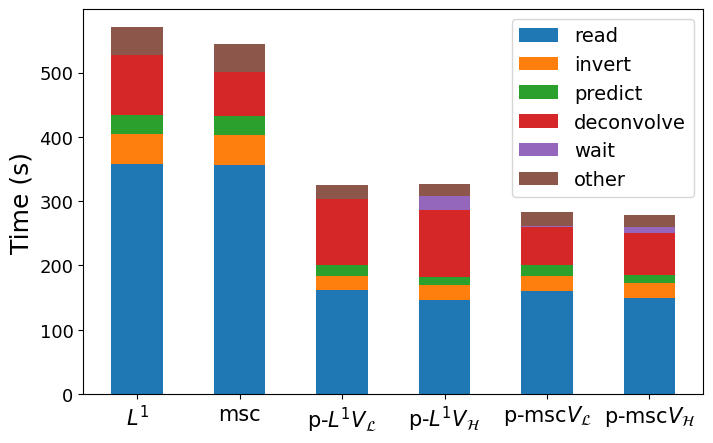

In [42]:
fig, ax = plt.subplots()

bottom = numpy.zeros(6)

for i, curr_breakdown in enumerate(breakdowns_parallel):
    curr_timings = None
    if i == 4:
        curr_timings = [0, 0, mid_timings_vl[i], mid_timings_vh[i], mid_timings_mscp_vl[i], mid_timings_mscp_vh[i]]
    elif i > 4:
        curr_timings = [mid_timings_serial[i - 1], mid_timings_msc[i - 1], mid_timings_vl[i], mid_timings_vh[i], mid_timings_mscp_vl[i], mid_timings_mscp_vh[i]]
    else:
        curr_timings = [mid_timings_serial[i], mid_timings_msc[i], mid_timings_vl[i], mid_timings_vh[i], mid_timings_mscp_vl[i], mid_timings_mscp_vh[i]]
    
    p = ax.bar(labels, curr_timings, width, label=curr_breakdown, bottom=bottom)
    bottom += curr_timings

ax.legend(loc="upper right", fontsize=14)
plt.ylabel("Time (s)", fontsize=18)
plt.xticks(fontsize=15)
plt.yticks(fontsize=13)
plt.locator_params(axis='y', nbins=6)

plt.show()

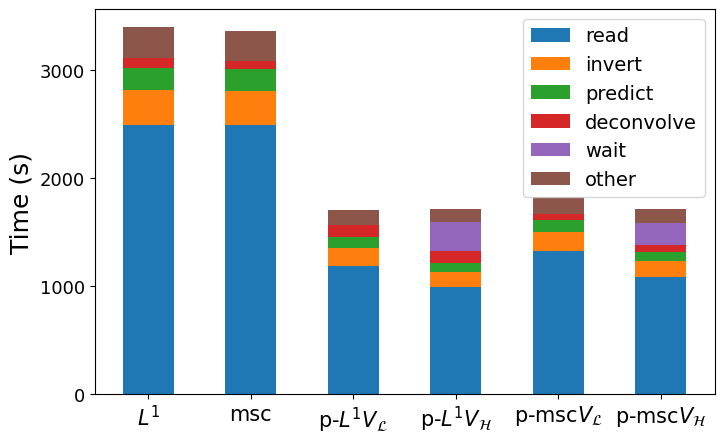

In [43]:
fig, ax = plt.subplots()

bottom = numpy.zeros(6)

for i, curr_breakdown in enumerate(breakdowns_parallel):
    curr_timings = None
    if i == 4:
        curr_timings = [0, 0, large_timings_vl[i], large_timings_vh[i], large_timings_mscp_vl[i], large_timings_mscp_vh[i]]
    elif i > 4:
        curr_timings = [large_timings_serial[i - 1], large_timings_msc[i - 1], large_timings_vl[i], large_timings_vh[i], large_timings_mscp_vl[i], large_timings_mscp_vh[i]]
    else:
        curr_timings = [large_timings_serial[i], large_timings_msc[i], large_timings_vl[i], large_timings_vh[i], large_timings_mscp_vl[i], large_timings_mscp_vh[i]]
    
    p = ax.bar(labels, curr_timings, width, label=curr_breakdown, bottom=bottom)
    bottom += curr_timings

ax.legend(loc="upper right", fontsize=14)
plt.ylabel("Time (s)", fontsize=18)
plt.xticks(fontsize=15)
plt.yticks(fontsize=13)
plt.locator_params(axis='y', nbins=6)

plt.show()